# Credit Score Classification

## Libraries and Packages


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    balanced_accuracy_score, fbeta_score, roc_auc_score,
    precision_recall_curve, auc, precision_score, recall_score,
    roc_curve,f1_score
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
import warnings
from catboost import CatBoostClassifier
warnings.filterwarnings('ignore')


/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Loading Data

In [2]:
data = pd.read_csv("/Users/user/Desktop/CreditScoreClassification/train.csv", low_memory = False)

data.head(n=1)
#raw_data.describe()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.82262,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good


In [3]:
pd.set_option('display.max_columns', None)
data.head(n=1)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.0,_,809.98,26.82262,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good


In [5]:
loan_type = data[data['ID'] == '0x1602']['Type_of_Loan'].values[0]
loan_type


'Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan'

In [3]:
#data.info()
data.dtypes
#pd.unique(data['Type_of_Loan']).tolist()

ID                           object
Customer_ID                  object
Month                        object
Name                         object
Age                          object
SSN                          object
Occupation                   object
Annual_Income                object
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                  object
Type_of_Loan                 object
Delay_from_due_date           int64
Num_of_Delayed_Payment       object
Changed_Credit_Limit         object
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age           object
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly      object
Payment_Behaviour            object
Monthly_Balance              object
Credit_Score                

In [4]:
data.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [5]:
for col in data.columns:
    print(f"Column '{col}' has {data[col].isna().sum()} missing values.")


Column 'ID' has 0 missing values.
Column 'Customer_ID' has 0 missing values.
Column 'Month' has 0 missing values.
Column 'Name' has 9985 missing values.
Column 'Age' has 0 missing values.
Column 'SSN' has 0 missing values.
Column 'Occupation' has 0 missing values.
Column 'Annual_Income' has 0 missing values.
Column 'Monthly_Inhand_Salary' has 15002 missing values.
Column 'Num_Bank_Accounts' has 0 missing values.
Column 'Num_Credit_Card' has 0 missing values.
Column 'Interest_Rate' has 0 missing values.
Column 'Num_of_Loan' has 0 missing values.
Column 'Type_of_Loan' has 11408 missing values.
Column 'Delay_from_due_date' has 0 missing values.
Column 'Num_of_Delayed_Payment' has 7002 missing values.
Column 'Changed_Credit_Limit' has 0 missing values.
Column 'Num_Credit_Inquiries' has 1965 missing values.
Column 'Credit_Mix' has 0 missing values.
Column 'Outstanding_Debt' has 0 missing values.
Column 'Credit_Utilization_Ratio' has 0 missing values.
Column 'Credit_History_Age' has 9030 mis

Months to numbers


In [6]:
data["Month"] = pd.to_datetime(data["Month"], format='%B').dt.month

In [7]:
data.head(n =20)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,1,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,2,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,3,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,4,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,5,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
5,0x1607,CUS_0xd40,6,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,27.262259,22 Years and 6 Months,No,49.574949,62.430172331195294,!@9#%8,340.4792117872438,Good
6,0x1608,CUS_0xd40,7,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,22.537593,22 Years and 7 Months,No,49.574949,178.3440674122349,Low_spent_Small_value_payments,244.5653167062043,Good
7,0x1609,CUS_0xd40,8,NaN,23,#F%$D@*&8,Scientist,19114.12,1824.843333,3,...,Good,809.98,23.933795,NaN,No,49.574949,24.785216509052056,High_spent_Medium_value_payments,358.12416760938714,Standard
8,0x160e,CUS_0x21b1,1,Rick Rothackerj,28_,004-07-5839,_______,34847.84,3037.986667,2,...,Good,605.03,24.464031,26 Years and 7 Months,No,18.816215,104.291825168246,Low_spent_Small_value_payments,470.69062692529184,Standard
9,0x160f,CUS_0x21b1,2,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,3037.986667,2,...,Good,605.03,38.550848,26 Years and 8 Months,No,18.816215,40.39123782853101,High_spent_Large_value_payments,484.5912142650067,Good


In [8]:
data = data.dropna(subset=['Credit_History_Age']).reset_index(drop=True)


In [9]:
 def convert_to_months(value):
    parts = value.split(' ')
    years = int(parts[0])
    months = int(parts[3])
    return years * 12 + months
data['Credit_History_Age_in_Months'] = data["Credit_History_Age"].apply(convert_to_months)

In [10]:

data['Credit_Score'] = data['Credit_Score'].replace({"Standard": "Good_Standard", "Good": "Good_Standard"})

data = pd.get_dummies(data, columns=['Credit_Score'], prefix='Credit_Score')

data.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_History_Age_in_Months,Credit_Score_Good_Standard,Credit_Score_Poor
0,0x1602,CUS_0xd40,1,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,265,True,False
1,0x1604,CUS_0xd40,3,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,267,True,False
2,0x1605,CUS_0xd40,4,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,268,True,False
3,0x1606,CUS_0xd40,5,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,269,True,False
4,0x1607,CUS_0xd40,6,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,27.262259,22 Years and 6 Months,No,49.574949,62.430172331195294,!@9#%8,340.4792117872438,270,True,False


In [11]:
print(data.columns)


Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_History_Age_in_Months', 'Credit_Score_Good_Standard',
       'Credit_Score_Poor'],
      dtype='object')


In [12]:

numeric_columns = ['Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 
                   'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 
                   'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 
                   'Credit_Utilization_Ratio', 'Total_EMI_per_month', 
                   'Amount_invested_monthly', 'Monthly_Balance','Credit_History_Age_in_Months','Credit_Score_Poor',
                   'Credit_Score_Good_Standard'
                  ]

for column in numeric_columns:

    data[column] = data[column].astype(str).replace(r'_', '', regex=True)

    data[column] = pd.to_numeric(data[column], errors='coerce')

data.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_History_Age_in_Months,Credit_Score_Good_Standard,Credit_Score_Poor
0,0x1602,CUS_0xd40,1,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,26.822620,22 Years and 1 Months,No,49.574949,80.415295,High_spent_Small_value_payments,312.494089,265,NaN,NaN
1,0x1604,CUS_0xd40,3,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,28.609352,22 Years and 3 Months,No,49.574949,81.699521,Low_spent_Medium_value_payments,331.209863,267,NaN,NaN
2,0x1605,CUS_0xd40,4,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,31.377862,22 Years and 4 Months,No,49.574949,199.458074,Low_spent_Small_value_payments,223.451310,268,NaN,NaN
3,0x1606,CUS_0xd40,5,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,24.797347,22 Years and 5 Months,No,49.574949,41.420153,High_spent_Medium_value_payments,341.489231,269,NaN,NaN
4,0x1607,CUS_0xd40,6,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,27.262259,22 Years and 6 Months,No,49.574949,62.430172,!@9#%8,340.479212,270,NaN,NaN


Age 

In [13]:
data["Age"] = data["Age"].apply(lambda x: ''.join(filter(str.isdigit, str(x))))
data["Age"] = pd.to_numeric(data["Age"], errors="coerce")
data["Age"] = data.groupby("Customer_ID")["Age"].transform("median")
data["Age"] = data["Age"].fillna(0).astype(int)

Monthy Income

In [14]:

filtered_data = data[['Annual_Income', 'Monthly_Inhand_Salary']].dropna()
filtered_data['Annual_Income'] = pd.to_numeric(filtered_data['Annual_Income'], errors='coerce')


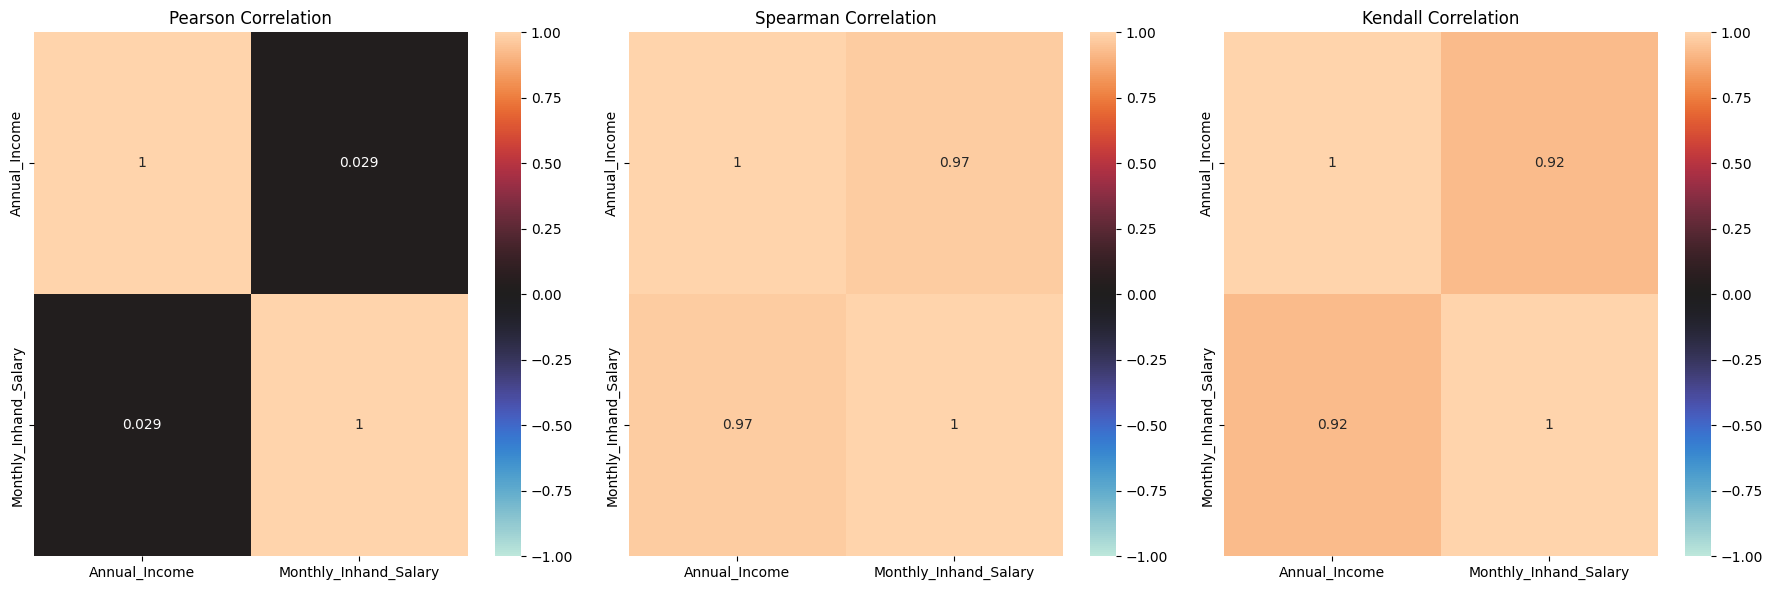

In [15]:
corr_methods = ['pearson', 'spearman', 'kendall']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, method in enumerate(corr_methods):
    corr_value = filtered_data.corr(method=method)
    sns.heatmap(corr_value, annot=True,  ax=axes[i], vmin=-1, vmax=1, center=0)
    axes[i].set_title(f"{method.capitalize()} Correlation")

plt.tight_layout()
plt.show()

In [16]:
data['Annual_Income'] = pd.to_numeric(data['Annual_Income'], errors='coerce')
data['Monthly_Inhand_Salary'] = pd.to_numeric(data['Monthly_Inhand_Salary'], errors='coerce')

data_reg = data.dropna(subset=['Monthly_Inhand_Salary'])

X_train = data_reg[['Annual_Income']]
y_train = data_reg['Monthly_Inhand_Salary']

model = LinearRegression()
model.fit(X_train, y_train)

missing_mask = data['Monthly_Inhand_Salary'].isna()

X_pred = data.loc[missing_mask, ['Annual_Income']]

if not X_pred.empty:
    predicted_values = model.predict(X_pred)
    data.loc[X_pred.index, 'Monthly_Inhand_Salary'] = predicted_values
    print("Missing values successfully filled!")
else:
    print("Still no valid Annual_Income values available for missing Monthly_Inhand_Salary!")

print(f"Intercept: {model.intercept_}")
print(f"Coefficient: {model.coef_[0]}")


Missing values successfully filled!
Intercept: 4188.454622499172
Coefficient: 6.43238920795772e-05


In [17]:
data.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_History_Age_in_Months,Credit_Score_Good_Standard,Credit_Score_Poor
0,0x1602,CUS_0xd40,1,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,26.822620,22 Years and 1 Months,No,49.574949,80.415295,High_spent_Small_value_payments,312.494089,265,NaN,NaN
1,0x1604,CUS_0xd40,3,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,4189.684117,3,...,28.609352,22 Years and 3 Months,No,49.574949,81.699521,Low_spent_Medium_value_payments,331.209863,267,NaN,NaN
2,0x1605,CUS_0xd40,4,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,4189.684117,3,...,31.377862,22 Years and 4 Months,No,49.574949,199.458074,Low_spent_Small_value_payments,223.451310,268,NaN,NaN
3,0x1606,CUS_0xd40,5,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,24.797347,22 Years and 5 Months,No,49.574949,41.420153,High_spent_Medium_value_payments,341.489231,269,NaN,NaN
4,0x1607,CUS_0xd40,6,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,4189.684117,3,...,27.262259,22 Years and 6 Months,No,49.574949,62.430172,!@9#%8,340.479212,270,NaN,NaN


In [18]:
print(f"Missing Monthly_Inhand_Salary count: {data['Monthly_Inhand_Salary'].isna().sum()}")
print(f"Shape of X_pred before predicting: {X_pred.shape}")
print(X_pred.head())  


Missing Monthly_Inhand_Salary count: 0
Shape of X_pred before predicting: (13667, 1)
    Annual_Income
1        19114.12
2        19114.12
4        19114.12
9        34847.84
12       34847.84


In [19]:
np.unique(data['Payment_Behaviour'])

array(['!@9#%8', 'High_spent_Large_value_payments',
       'High_spent_Medium_value_payments',
       'High_spent_Small_value_payments',
       'Low_spent_Large_value_payments',
       'Low_spent_Medium_value_payments',
       'Low_spent_Small_value_payments'], dtype=object)

In [20]:
target_value = '!@9#%8'

count = data['Payment_Behaviour'].eq(target_value).sum()

print(f"The value '{target_value}' appears {count} times.")


The value '!@9#%8' appears 6911 times.


In [21]:
data = data[data['Payment_Behaviour'] != target_value]

In [22]:
Payment_Behaviour_Mapping = {
    'High_spent_Large_value_payments' :6,
    'High_spent_Medium_value_payments' :5,
    'High_spent_Small_value_payments' :4,
    'Low_spent_Large_value_payments' :3,
    'Low_spent_Medium_value_payments' :2,
    'Low_spent_Small_value_payments' :1   
}

data['Payment_Behaviour_Ordinal'] = data['Payment_Behaviour'].map(Payment_Behaviour_Mapping)


In [23]:
data.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_History_Age_in_Months', 'Credit_Score_Good_Standard',
       'Credit_Score_Poor', 'Payment_Behaviour_Ordinal'],
      dtype='object')

In [24]:
numeric_columns.append("Age")

In [25]:
numeric_columns

['Annual_Income',
 'Monthly_Inhand_Salary',
 'Num_Bank_Accounts',
 'Num_Credit_Card',
 'Interest_Rate',
 'Num_of_Loan',
 'Delay_from_due_date',
 'Num_of_Delayed_Payment',
 'Changed_Credit_Limit',
 'Num_Credit_Inquiries',
 'Outstanding_Debt',
 'Credit_Utilization_Ratio',
 'Total_EMI_per_month',
 'Amount_invested_monthly',
 'Monthly_Balance',
 'Credit_History_Age_in_Months',
 'Credit_Score_Poor',
 'Credit_Score_Good_Standard',
 'Age']

In [26]:
data.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_History_Age_in_Months', 'Credit_Score_Good_Standard',
       'Credit_Score_Poor', 'Payment_Behaviour_Ordinal'],
      dtype='object')

In [27]:

selected_columns = [
    'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
    'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
    'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
    'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance',
    'Credit_History_Age_in_Months', 'Credit_Score_Poor',
    'Payment_Behaviour_Ordinal', 'Age', 'Credit_Score_Good_Standard'
]

existing_columns = [col for col in selected_columns if col in data.columns]

new_data = data[existing_columns].copy()

print(new_data.head())


   Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  Num_Credit_Card  \
0       19114.12            1824.843333                  3                4   
1       19114.12            4189.684117                  3                4   
2       19114.12            4189.684117                  3                4   
3       19114.12            1824.843333                  3                4   
5       19114.12            1824.843333                  3                4   

   Interest_Rate  Num_of_Loan  Delay_from_due_date  Num_of_Delayed_Payment  \
0              3            4                    3                     7.0   
1              3            4                    3                     7.0   
2              3            4                    5                     4.0   
3              3            4                    6                     NaN   
5              3            4                    3                     8.0   

   Changed_Credit_Limit  Num_Credit_Inquiries  Outstandi

In [28]:
new_data.columns

Index(['Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance',
       'Credit_History_Age_in_Months', 'Credit_Score_Poor',
       'Payment_Behaviour_Ordinal', 'Age', 'Credit_Score_Good_Standard'],
      dtype='object')

In [29]:
correlation_data = new_data
correlation_matrix = correlation_data.corr(method='spearman')

print(correlation_matrix)

                              Annual_Income  Monthly_Inhand_Salary  \
Annual_Income                      1.000000               0.906163   
Monthly_Inhand_Salary              0.906163               1.000000   
Num_Bank_Accounts                 -0.259767              -0.225752   
Num_Credit_Card                   -0.191096              -0.169799   
Interest_Rate                     -0.277404              -0.244943   
Num_of_Loan                       -0.225196              -0.197773   
Delay_from_due_date               -0.238822              -0.209399   
Num_of_Delayed_Payment            -0.252902              -0.221569   
Changed_Credit_Limit              -0.154624              -0.136287   
Num_Credit_Inquiries              -0.265551              -0.234967   
Outstanding_Debt                  -0.271801              -0.244086   
Credit_Utilization_Ratio           0.137480               0.128698   
Total_EMI_per_month                0.450921               0.429171   
Amount_invested_mont

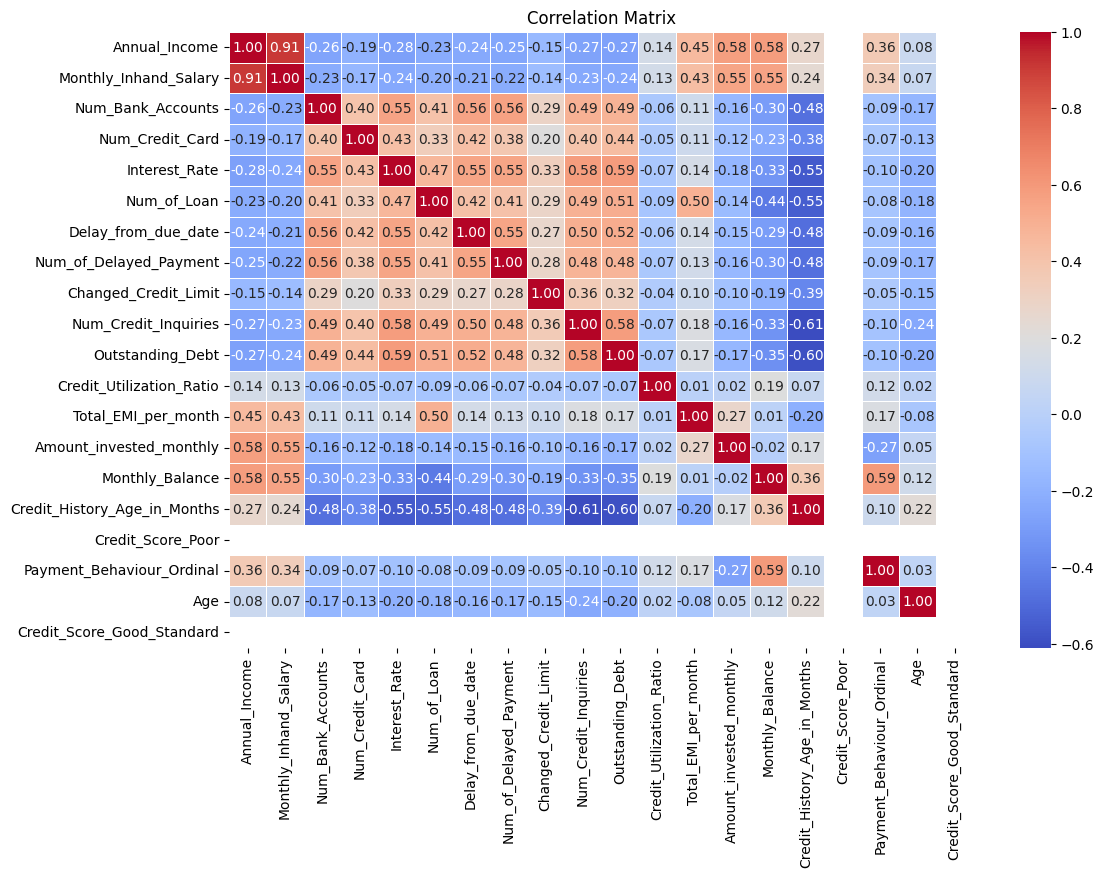

In [30]:

plt.figure(figsize=(12, 8))


sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)


plt.title("Correlation Matrix")
plt.show()


In [42]:
pd.set_option('display.max_columns', None)

data.head(1)



,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_History_Age_in_Months,Credit_Score_Good_Standard,Credit_Score_Poor,Payment_Behaviour_Ordinal
0,0x1602,CUS_0xd40,1,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7.0,11.27,4.0,_,809.98,26.82262,22 Years and 1 Months,No,49.574949,80.415295,High_spent_Small_value_payments,312.494089,265,NaN,NaN,4


In [41]:
min_max_values = data[numeric_columns].agg(['min', 'max']).transpose()

print(min_max_values)

                                       min           max
Annual_Income                 7.005930e+03  2.419806e+07
Monthly_Inhand_Salary         3.036454e+02  1.520463e+04
Num_Bank_Accounts            -1.000000e+00  1.798000e+03
Num_Credit_Card               0.000000e+00  1.499000e+03
Interest_Rate                 1.000000e+00  5.797000e+03
Num_of_Loan                  -1.000000e+02  1.485000e+03
Delay_from_due_date          -5.000000e+00  6.700000e+01
Num_of_Delayed_Payment       -3.000000e+00  4.397000e+03
Changed_Credit_Limit         -6.450000e+00  3.697000e+01
Num_Credit_Inquiries          0.000000e+00  2.594000e+03
Outstanding_Debt              2.300000e-01  4.998070e+03
Credit_Utilization_Ratio      2.010077e+01  5.000000e+01
Total_EMI_per_month           0.000000e+00  8.233100e+04
Amount_invested_monthly       0.000000e+00  1.000000e+04
Monthly_Balance              -3.333333e+26  1.602041e+03
Credit_History_Age_in_Months  1.000000e+00  4.040000e+02
Credit_Score_Poor              

# Softmax model

In [33]:
new_data = new_data.dropna()

X = new_data.drop(columns=['Credit_Score_Poor', 'Credit_Score_Good_Standard']) 
y = new_data['Credit_Score_Poor'] 

scaler = StandardScaler()
X_scaled_lr = scaler.fit_transform(X)

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_scaled_lr, y, test_size=0.2, random_state=42, stratify=y)

model_lr = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model_lr.fit(X_train_lr, y_train_lr)

y_pred_lr = model_lr.predict(X_test_lr)

ValueError: Found array with 0 sample(s) (shape=(0, 18)) while a minimum of 1 is required by StandardScaler.

## Confusion Matrix for Logistic Regression

In [ ]:

conf_matrix = confusion_matrix(y_test_lr, y_pred_lr)


plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=np.unique(y_test_lr), yticklabels=np.unique(y_test_lr))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Metrics for Mult. Logistic Model

In [ ]:



accuracy_lr = accuracy_score(y_test_lr, y_pred_lr)
precision_lr = precision_score(y_test_lr, y_pred_lr, average='weighted')  
recall_lr = recall_score(y_test_lr, y_pred_lr, average='weighted')


print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")


### Balanced Accuracy, F_Beta score, AUC Score (LG)

In [ ]:
fbeta_lr = fbeta_score(y_test_lr, y_pred_lr, beta=2)

balanced_acc_lr = balanced_accuracy_score(y_test_lr, y_pred_lr)

y_prob_lr = model_lr.predict_proba(X_test_lr)[:, 1]
auc_score_lr = roc_auc_score(y_test_lr, y_prob_lr)

print(f"Balanced Accuracy: {balanced_acc_lr:.4f}")
print(f"F1 Score (F-beta with β=2): {fbeta_lr:.4f}")
print(f"AUC Score: {auc_score_lr:.4f}")

## Precision-Recall curve (LG)

In [ ]:

# precision_lr, recall_lr, _ = precision_recall_curve(y_test_lr, y_prob_lr)

# pr_auc = auc(recall_lr, precision_lr)

# plt.figure(figsize=(8, 6))
# plt.plot(recall_lr, precision_lr, marker='.', label=f'PR AUC = {pr_auc:.4f}')
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Precision-Recall Curve')
# plt.legend()
# plt.grid()
# plt.show()

## ROC AUC Curve (LG)

In [ ]:
fpr, tpr, _ = roc_curve(y_test_lr, y_prob_lr)
roc_auc = roc_auc_score(y_test_lr, y_prob_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, marker='.', label=f'ROC AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

## Decision Tree

In [ ]:

X = new_data.drop(columns=['Credit_Score_Poor', 'Credit_Score_Good_Standard']) 
y = new_data['Credit_Score_Poor']  

X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled_dt = scaler.fit_transform(X_train_dt)
X_test_scaled_dt = scaler.transform(X_test_dt)



In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled_dt, y_train_dt)

In [ ]:
y_pred_dt = dt_model.predict(X_test_scaled_dt)
y_pred_prob_dt = dt_model.predict_proba(X_test_scaled_dt)[:, 1]

### Metrics (Decision Tree)

In [ ]:

accuracy_dt = accuracy_score(y_test_dt, y_pred_dt)
balanced_acc_dt = balanced_accuracy_score(y_test_dt, y_pred_dt) 
recall_dt = recall_score(y_test_dt, y_pred_dt)
precision_dt = precision_score(y_test_dt, y_pred_dt)
f_beta_dt = fbeta_score(y_test_dt, y_pred_dt, beta=2)
auc_dt = roc_auc_score(y_test_dt, y_pred_prob_dt)

print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"Balanced Accuracy(DT): {balanced_acc_dt:.4f}")
print(f"F-beta Score (β=2)(DT): {f_beta_dt:.4f}")
print(f"AUC Score(DT): {auc_dt:.4f}")




### Confusion Matrix (DT)

In [34]:
cm_dt = confusion_matrix(y_test_dt, y_pred_dt)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues", xticklabels=["Good", "Poor"], yticklabels=["Good", "Poor"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Decision Tree)")
plt.show()

NameError: name 'y_test_dt' is not defined

In [35]:

print("Confusion Matrix:\n", cm_dt)


NameError: name 'cm_dt' is not defined

### Feature Importance (DT)

In [ ]:
feature_importance_dt = dt_model.feature_importances_
features = X.columns


plt.figure(figsize=(10,6))
sns.barplot(x=feature_importance_dt, y=features)
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance in Decision Tree")
plt.show()

### Precision Recall Curve (DT)

In [ ]:
fpr, tpr, _ = roc_curve(y_test_dt, y_pred_prob_dt)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_dt:.2f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')  
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Decision Tree Classifier')
plt.legend()
plt.grid()
plt.show()


## CatBoost

In [36]:

selected_columns_cat = [
    'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
    'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
    'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
    'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance',
    'Credit_History_Age_in_Months',
    'Payment_Behaviour_Ordinal', 'Age', 'Occupation',
    'Type_of_Loan', 'Payment_Behaviour'
]

existing_columns_cat = [col for col in selected_columns_cat if col in data.columns]

cat_features = [col for col in existing_columns_cat if data[col].dtype == 'object']


new_data_cat = data[existing_columns_cat].copy()

print(new_data_cat.head())


   Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  Num_Credit_Card  \
0       19114.12            1824.843333                  3                4   
1       19114.12            4189.684117                  3                4   
2       19114.12            4189.684117                  3                4   
3       19114.12            1824.843333                  3                4   
5       19114.12            1824.843333                  3                4   

   Interest_Rate  Num_of_Loan  Delay_from_due_date  Num_of_Delayed_Payment  \
0              3            4                    3                     7.0   
1              3            4                    3                     7.0   
2              3            4                    5                     4.0   
3              3            4                    6                     NaN   
5              3            4                    3                     8.0   

   Changed_Credit_Limit  Num_Credit_Inquiries  ...  Cred

In [37]:
X = new_data_cat
y = data['Credit_Score_Poor'] 

In [38]:
for col in cat_features:
    new_data_cat[col] = new_data_cat[col].fillna("Unknown").astype(str)

for col in new_data_cat.select_dtypes(exclude=['object']).columns:
    new_data_cat[col] = new_data_cat[col].fillna(new_data_cat[col].median())

    



In [49]:
X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(X, y, test_size=0.2, random_state=42)

model_cb = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1, cat_features=cat_features, verbose=50)

model_cb.fit(X_train_cb, y_train_cb)

y_pred_cb = model_cb.predict(X_test_cb)


0:	learn: 0.6422281	total: 96.3ms	remaining: 19.2s
50:	learn: 0.3442850	total: 1.87s	remaining: 5.47s
100:	learn: 0.3316784	total: 4.33s	remaining: 4.24s
150:	learn: 0.3226497	total: 6.83s	remaining: 2.21s
199:	learn: 0.3152894	total: 8.94s	remaining: 0us


### Feature importance

Feature Importance:
                         Feature  Importance
19                  Type_of_Loan   20.432621
3                Num_Credit_Card   14.312017
10              Outstanding_Debt   13.242408
4                  Interest_Rate    9.259216
18                    Occupation    7.502758
6            Delay_from_due_date    5.868366
8           Changed_Credit_Limit    4.548835
5                    Num_of_Loan    2.854275
2              Num_Bank_Accounts    2.806470
14               Monthly_Balance    2.730902
9           Num_Credit_Inquiries    2.503007
7         Num_of_Delayed_Payment    2.385820
12           Total_EMI_per_month    2.311499
16     Payment_Behaviour_Ordinal    1.707014
0                  Annual_Income    1.600477
15  Credit_History_Age_in_Months    1.555444
20             Payment_Behaviour    1.069874
1          Monthly_Inhand_Salary    1.059556
17                           Age    1.026866
13       Amount_invested_monthly    0.952146
11      Credit_Utilization_Ratio   

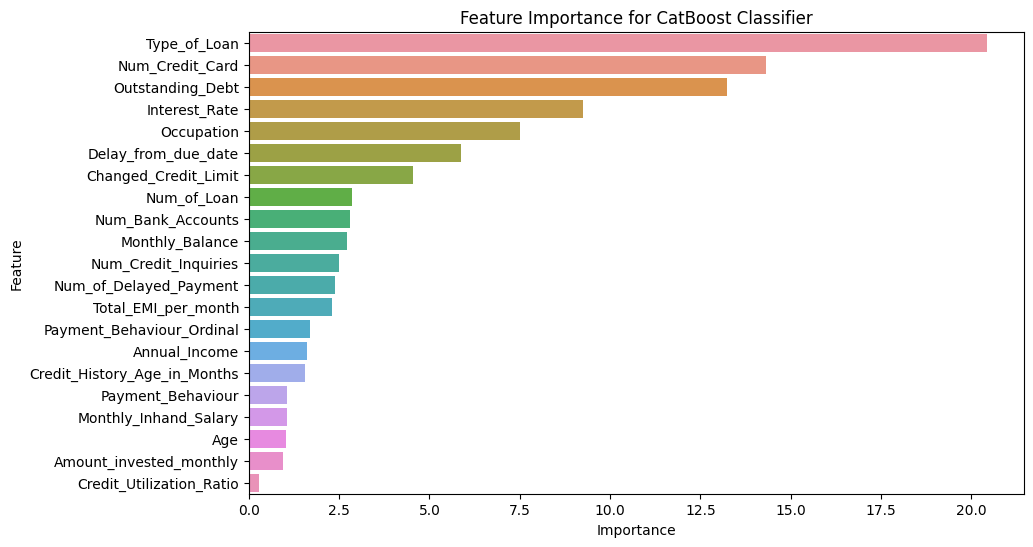

In [50]:
feature_importance = model_cb.get_feature_importance()
feature_names = X_train_cb.columns 

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

print("Feature Importance:")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance for CatBoost Classifier')
plt.show()

### Metrics  (CatBoost)

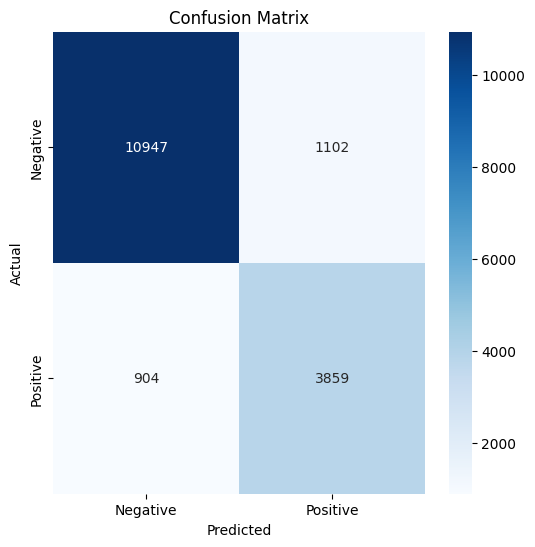

In [51]:
conf_matrix_cb = confusion_matrix(y_test_cb, y_pred_cb)


plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix_cb, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [52]:


y_pred_cb = model_cb.predict(X_test_cb)
y_pred_cb = y_pred_cb.astype(int)

accuracy_cb = accuracy_score(y_test_cb, y_pred_cb)
precision_cb = precision_score(y_test_cb, y_pred_cb, average="binary")  
recall_cb = recall_score(y_test_cb, y_pred_cb, average="binary")
f1_cb = f1_score(y_test_cb, y_pred_cb, average="binary")
balanced_acc_cb = balanced_accuracy_score(y_test_cb, y_pred_cb)

y_pred_proba_cb = model_cb.predict_proba(X_test_cb)[:, 1]  
auc_cb = roc_auc_score(y_test_cb, y_pred_proba_cb)

print(f"Accuracy: {accuracy_cb:.2f}")
print(f"Precision: {precision_cb:.4f}")
print(f"Recall: {recall_cb:.4f}")
print(f"F1-score: {f1_cb:.4f}")
print(f"Balanced Accuracy: {balanced_acc_cb:.4f}")
print(f"AUC: {auc_cb:.4f}")


Accuracy: 0.88
Precision: 0.7779
Recall: 0.8102
F1-score: 0.7937
Balanced Accuracy: 0.8594
AUC: 0.9327


### ROC AUC CURVE (CatBoost)

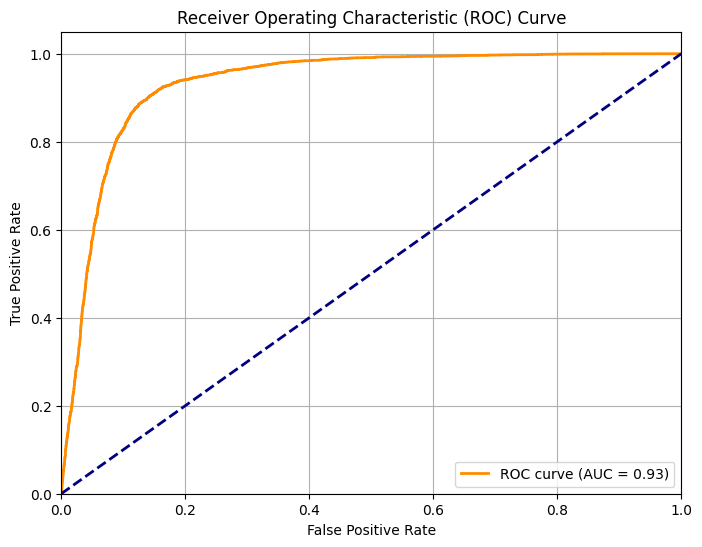

In [53]:
y_pred_proba_cb = model_cb.predict_proba(X_test_cb)[:, 1]  

fpr_cb, tpr_cb, thresholds = roc_curve(y_test_cb, y_pred_proba_cb)

roc_auc_cb = auc(fpr_cb, tpr_cb)


plt.figure(figsize=(8, 6))
plt.plot(fpr_cb, tpr_cb, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_cb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Random Forest

In [54]:
X = new_data.drop(columns=['Credit_Score_Poor', 'Credit_Score_Good_Standard']) 
y = new_data['Credit_Score_Poor']  


X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled_rf = scaler.fit_transform(X_train_rf)
X_test_scaled_rf = scaler.transform(X_test_rf)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42) 

rf_model.fit(X_train_scaled_rf, y_train_rf)


y_pred_rf = rf_model.predict(X_test_scaled_rf)
y_prob_rf = rf_model.predict_proba(X_test_scaled_rf)[:, 1]  


### Confusion Matrix (RF)

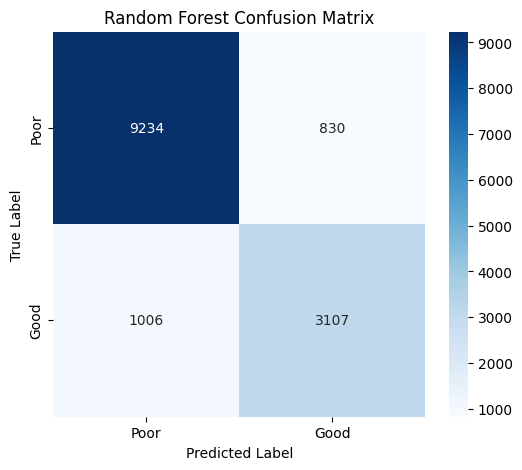

In [55]:
cm_rf = confusion_matrix(y_test_rf, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", xticklabels=["Poor", "Good"], yticklabels=["Poor", "Good"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest Confusion Matrix")
plt.show()


### Metrics (RF)

In [56]:

accuracy_rf = accuracy_score(y_test_rf, y_pred_rf)  
precision_rf = precision_score(y_test_rf, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test_rf, y_pred_rf, average='weighted')


print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Precision: {precision_rf:.4f}")
print(f"Random Forest Recall: {recall_rf:.4f}")



Random Forest Accuracy: 0.8705
Random Forest Precision: 0.8691
Random Forest Recall: 0.8705


### Balanced Accuracy, F_Beta, AUC (RF)

In [57]:
fbeta_rf = fbeta_score(y_test_rf, y_pred_rf, beta=2) 
auc_rf = roc_auc_score(y_test_rf, y_prob_rf)
balanced_acc_rf = balanced_accuracy_score(y_test_rf, y_pred_rf)

print(f"Random Forest F-beta (β=2): {fbeta_rf:.4f}")
print(f"Random Forest AUC: {auc_rf:.4f}")
print(f"Random Forest Balanced Accuracy: {balanced_acc_rf:.4f}")

Random Forest F-beta (β=2): 0.7619
Random Forest AUC: 0.9284
Random Forest Balanced Accuracy: 0.8365


### Precision Recall Curve  (RF)

In [58]:
# precision_rf, recall_rf, _ = precision_recall_curve(y_test_rf, y_prob_rf)
# pr_auc = auc(recall_rf, precision_rf)


# plt.figure(figsize=(8, 6))
# plt.plot(recall_rf, precision_rf, marker='.', label=f'PR AUC (RF) = {pr_auc:.4f}')
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Precision-Recall Curve (RF)')
# plt.legend()
# plt.grid()
# plt.show()

### ROC AUC CURVE (RF)

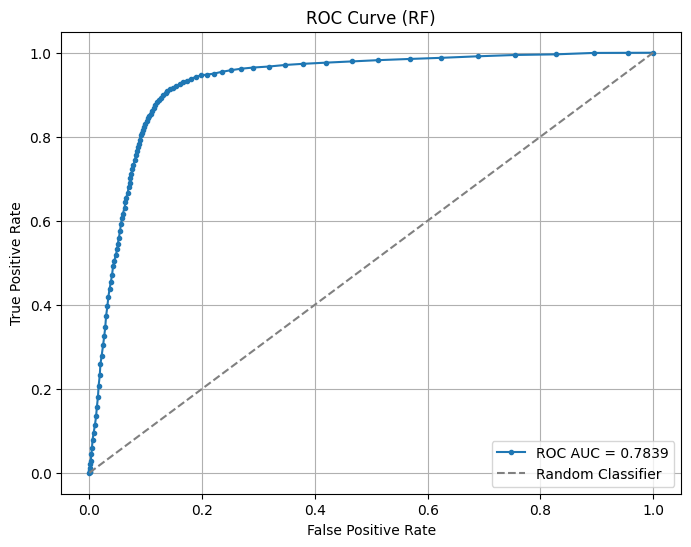

In [59]:
fpr_rf, tpr_rf, _ = roc_curve(y_test_rf, y_prob_rf)
roc_auc_rf = roc_auc_score(y_test_rf, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, marker='.', label=f'ROC AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (RF)')
plt.legend()
plt.grid()
plt.show()

## XGBoost

In [60]:
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled_xgb = scaler.fit_transform(X_train_xgb)
X_test_scaled_xgb = scaler.transform(X_test_xgb)


xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',  
    eval_metric='logloss',  
    use_label_encoder=False,
    random_state=42
)

xgb_model.fit(X_train_scaled_xgb, y_train_xgb)


y_pred_xgb = xgb_model.predict(X_test_scaled_xgb)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled_xgb)[:, 1] 


### Confusion Matrix (XGB)

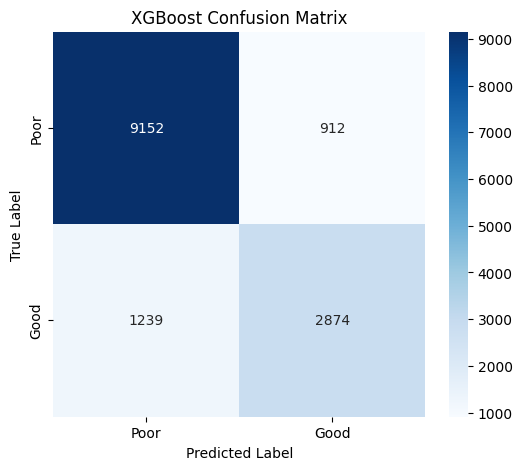

In [61]:
cm_xgb = confusion_matrix(y_test_xgb, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues", xticklabels=["Poor", "Good"], yticklabels=["Poor", "Good"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("XGBoost Confusion Matrix")
plt.show()


## Metrics (XGB)

In [62]:

accuracy_xgb = accuracy_score(y_test_xgb, y_pred_xgb)
precision_xgb = precision_score(y_test_xgb, y_pred_xgb, average='weighted')
recall_xgb = recall_score(y_test_xgb, y_pred_xgb, average='weighted')

fbeta_xgb = fbeta_score(y_test_xgb, y_pred_xgb, beta=2)  
auc_xgb = roc_auc_score(y_test_xgb, y_prob_xgb)
balanced_acc_xgb = balanced_accuracy_score(y_test_xgb, y_pred_xgb)

print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")
print(f"XGBoost Precision: {precision_xgb:.4f}")
print(f"XGBoost Recall: {recall_xgb:.4f}")
print(f"XGBoost F-beta (β=2): {fbeta_xgb:.4f}")
print(f"XGBoost AUC: {auc_xgb:.4f}")
print(f"XGBoost Balanced Accuracy: {balanced_acc_xgb:.4f}")




XGBoost Accuracy: 0.8483
XGBoost Precision: 0.8455
XGBoost Recall: 0.8483
XGBoost F-beta (β=2): 0.7101
XGBoost AUC: 0.9026
XGBoost Balanced Accuracy: 0.8041


### Precision Recall curve (XGB)

In [63]:


# precision_xgb, recall_xgb, _ = precision_recall_curve(y_test_xgb, y_prob_xgb)
# pr_auc = auc(recall_xgb, precision_xgb)


# plt.figure(figsize=(8, 6))
# plt.plot(recall_xgb, precision_xgb, marker='.', label=f'PR AUC (XGB) = {pr_auc:.4f}')
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Precision-Recall Curve (XGB)')
# plt.legend()
# plt.grid()
# plt.show()

## Results&Conclusion

In [64]:
results = {
    "Decision Tree": {
        "Accuracy": accuracy_dt,
        "Precision": precision_dt,
        "Recall": recall_dt,
        "F-beta (β=2)": f_beta_dt,
        "AUC": auc_dt,
        "Balanced Accuracy": balanced_acc_dt
    },
    "Random Forest": {
        "Accuracy": accuracy_rf,
        "Precision": precision_rf,
        "Recall": recall_rf,
        "F-beta (β=2)": fbeta_rf,
        "AUC": auc_rf,
        "Balanced Accuracy": balanced_acc_rf
    },
    "XGBoost": {
        "Accuracy": accuracy_xgb,
        "Precision": precision_xgb,
        "Recall": recall_xgb,
        "F-beta (β=2)": fbeta_xgb,
        "AUC": auc_xgb,
        "Balanced Accuracy": balanced_acc_xgb
    },
    "Logistic Regression": {
        "Accuracy": accuracy_lr,
        "Precision": precision_lr,
        "Recall": recall_lr,
        "F-beta (β=2)": fbeta_lr,
        "AUC": auc_score_lr,
        "Balanced Accuracy": balanced_acc_lr
    }
}
results["CatBoost"] = {
    "Accuracy": accuracy_cb,
    "Precision": precision_cb,
    "Recall": recall_cb,
    "F-beta (β=2)": f1_cb, 
    "AUC": auc_cb,
    "Balanced Accuracy": balanced_acc_cb
}


df_results = pd.DataFrame(results).T
df_results = df_results.apply(pd.to_numeric, errors='coerce')

print(df_results)

                     Accuracy  Precision    Recall  F-beta (β=2)       AUC  \
Decision Tree        0.814770   0.677999  0.688549      0.686412  0.777452   
Random Forest        0.870494   0.869097  0.870494      0.761930  0.928353   
XGBoost              0.848275   0.845469  0.848275      0.710050  0.902562   
Logistic Regression  0.759258   0.742897  0.759258      0.429766  0.783929   
CatBoost             0.880680   0.777867  0.810204      0.793706  0.932668   

                     Balanced Accuracy  
Decision Tree                 0.777452  
Random Forest                 0.836469  
XGBoost                       0.804070  
Logistic Regression           0.652307  
CatBoost                      0.859372  


<Figure size 1200x600 with 0 Axes>

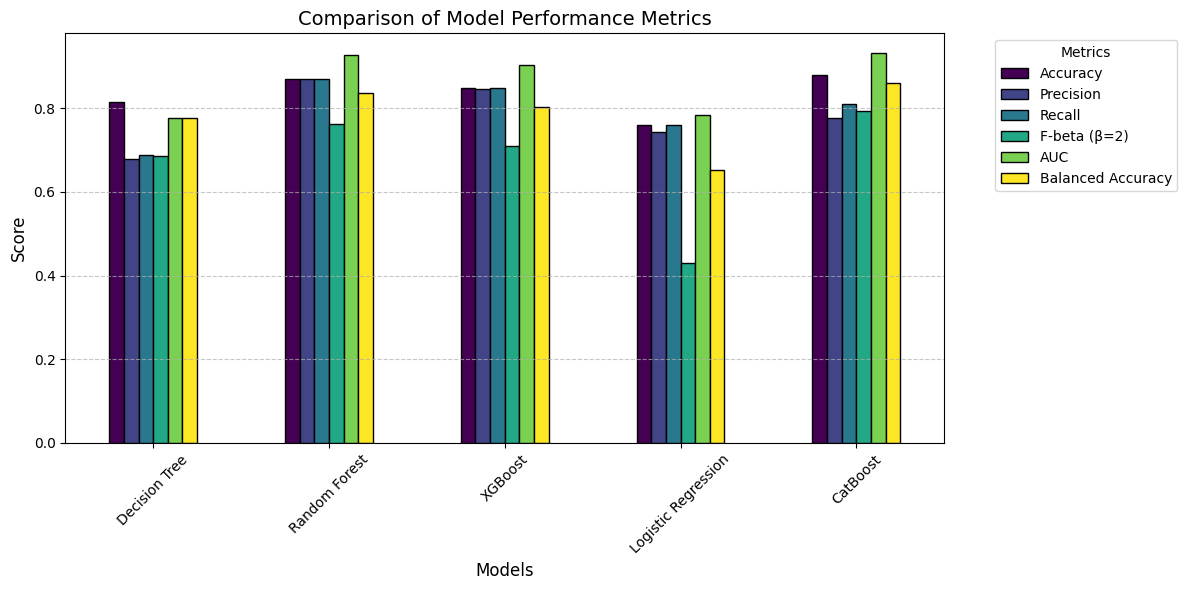

In [65]:

plt.figure(figsize=(12, 6))

df_results.plot(kind='bar', figsize=(12, 6), colormap='viridis', edgecolor='black')


plt.title("Comparison of Model Performance Metrics", fontsize=14)
plt.ylabel("Score", fontsize=12)
plt.xlabel("Models", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()


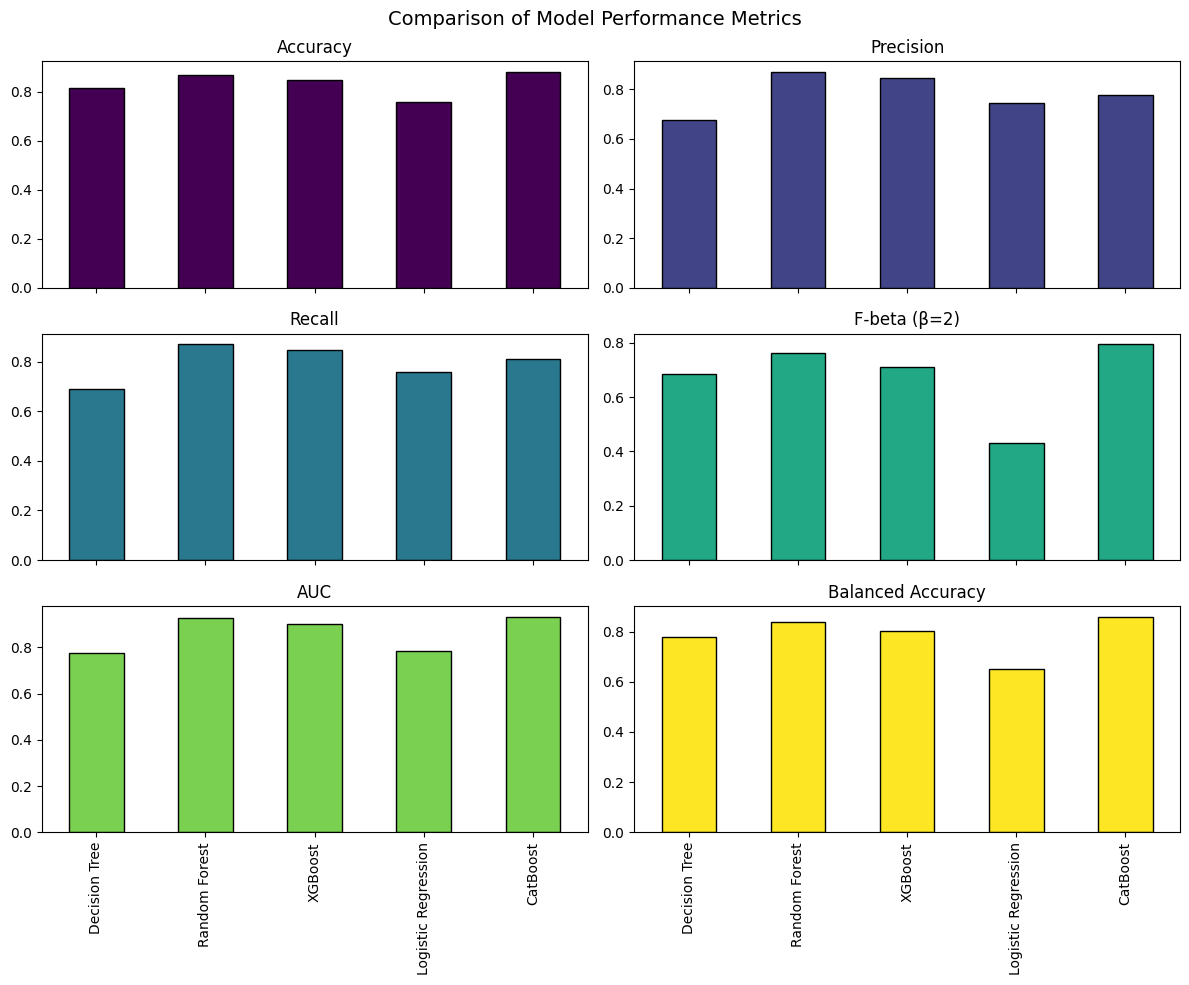

In [66]:
df_results.plot(kind='bar', subplots=True, layout=(3, 2), figsize=(12, 10), colormap='viridis', edgecolor='black', legend=False)
plt.suptitle("Comparison of Model Performance Metrics", fontsize=14)
plt.tight_layout()
plt.show()



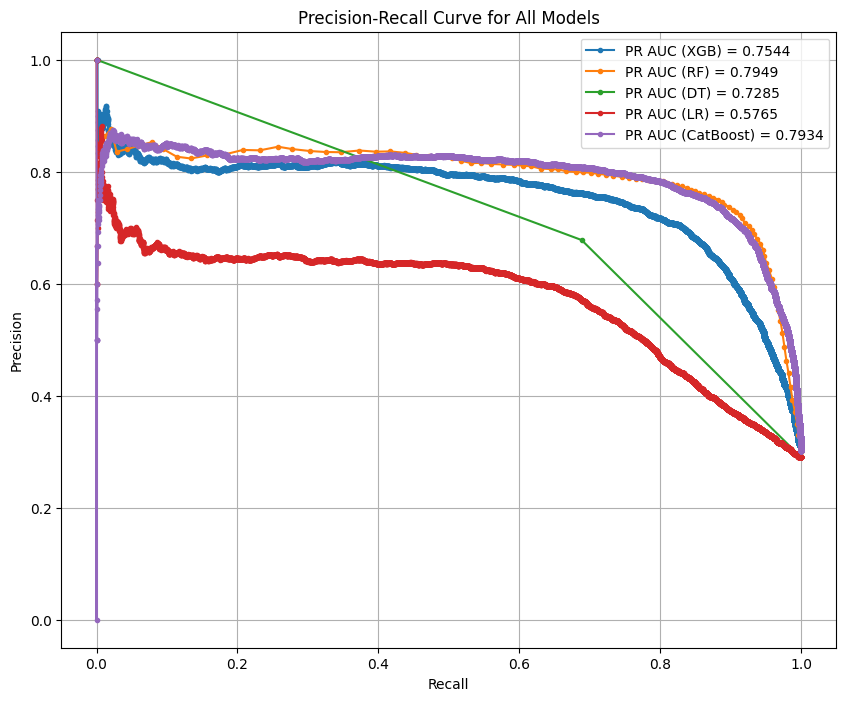

In [67]:
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test_xgb, y_prob_xgb)
pr_auc_xgb = auc(recall_xgb, precision_xgb)

precision_rf, recall_rf, _ = precision_recall_curve(y_test_rf, y_prob_rf)
pr_auc_rf = auc(recall_rf, precision_rf)

precision_cb, recall_cb, _ = precision_recall_curve(y_test_cb, y_pred_proba_cb)
pr_auc_cb = auc(recall_cb, precision_cb)

precision_dt, recall_dt, _ = precision_recall_curve(y_test_dt, y_pred_prob_dt)
pr_auc_dt = auc(recall_dt, precision_dt)

precision_lr, recall_lr, _ = precision_recall_curve(y_test_lr, y_prob_lr)
pr_auc_lr = auc(recall_lr, precision_lr)

plt.figure(figsize=(10, 8))

plt.plot(recall_xgb, precision_xgb, marker='.', label=f'PR AUC (XGB) = {pr_auc_xgb:.4f}')
plt.plot(recall_rf, precision_rf, marker='.', label=f'PR AUC (RF) = {pr_auc_rf:.4f}')
plt.plot(recall_dt, precision_dt, marker='.', label=f'PR AUC (DT) = {pr_auc_dt:.4f}')
plt.plot(recall_lr, precision_lr, marker='.', label=f'PR AUC (LR) = {pr_auc_lr:.4f}')
plt.plot(recall_cb, precision_cb, marker='.', label=f'PR AUC (CatBoost) = {pr_auc_cb:.4f}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for All Models')
plt.legend()
plt.grid(True)

plt.show()


## Validation and Learning curves

In [68]:
from sklearn.model_selection import learning_curve
warnings.filterwarnings('ignore')


## Validation Curve for Hyperparameters

Decision Tree - Max Depth

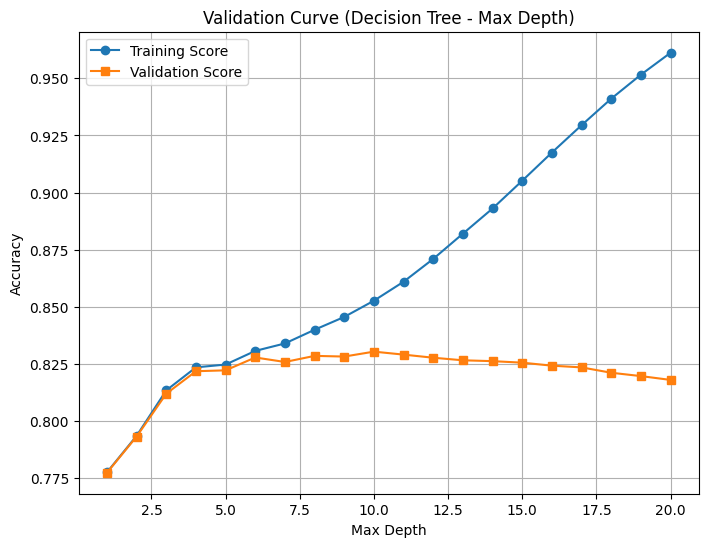

In [69]:
from sklearn.model_selection import validation_curve

param_range = np.arange(1, 21)  

train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X_train_scaled_dt, y_train_dt,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(param_range, train_mean, label="Training Score", marker="o")
plt.plot(param_range, val_mean, label="Validation Score", marker="s")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Validation Curve (Decision Tree - Max Depth)")
plt.legend()
plt.grid()
plt.show()


Random Forest - Number of Estimators

In [70]:
# param_range = np.arange(10, 210, 20)

# train_scores, val_scores = validation_curve(
#     RandomForestClassifier(random_state=42),
#     X_train_scaled_dt, y_train_dt,
#     param_name="n_estimators",
#     param_range=param_range,
#     cv=5,
#     scoring="accuracy",
#     n_jobs=-1
# )

# train_mean = np.mean(train_scores, axis=1)
# val_mean = np.mean(val_scores, axis=1)

# plt.figure(figsize=(8, 6))
# plt.plot(param_range, train_mean, label="Training Score", marker="o")
# plt.plot(param_range, val_mean, label="Validation Score", marker="s")
# plt.xlabel("Number of Trees")
# plt.ylabel("Accuracy")
# plt.title("Validation Curve (Random Forest - Estimators)")
# plt.legend()
# plt.grid()
# plt.show()


XGBoost - Learning Rate

In [71]:
# param_range = np.logspace(-3, 0, 10)

# train_scores, val_scores = validation_curve(
#     xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss"),
#     X_train_scaled_dt, y_train_dt,
#     param_name="learning_rate",
#     param_range=param_range,
#     cv=5,
#     scoring="accuracy",
#     n_jobs=-1
# )

# train_mean = np.mean(train_scores, axis=1)
# val_mean = np.mean(val_scores, axis=1)

# plt.figure(figsize=(8, 6))
# plt.plot(param_range, train_mean, label="Training Score", marker="o")
# plt.plot(param_range, val_mean, label="Validation Score", marker="s")
# plt.xlabel("Learning Rate")
# plt.ylabel("Accuracy")
# plt.xscale("log")
# plt.title("Validation Curve (XGBoost - Learning Rate)")
# plt.legend()
# plt.grid()
# plt.show()


## Grid search for catboost

In [72]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'iterations': [200, 220],  
    'depth': [4, 6, 8],  
    'learning_rate': [0.01, 0.1, 0.2],  
    'l2_leaf_reg': [1, 3, 5],  
}


grid_search = GridSearchCV(
    estimator=model_cb,  
    param_grid=param_grid,  
    scoring='accuracy',  
    cv=3,  
    n_jobs=-1, 
    verbose=2
)


grid_search.fit(X_train_cb, y_train_cb)


print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)


Fitting 3 folds for each of 54 candidates, totalling 162 fits
0:	learn: 0.6399173	total: 62.4ms	remaining: 13.7s
50:	learn: 0.3308956	total: 2.13s	remaining: 7.04s
100:	learn: 0.3126851	total: 4.3s	remaining: 5.07s
150:	learn: 0.2975675	total: 6.63s	remaining: 3.03s
200:	learn: 0.2843798	total: 8.95s	remaining: 846ms
219:	learn: 0.2800187	total: 9.84s	remaining: 0us
Best Parameters: {'depth': 8, 'iterations': 220, 'l2_leaf_reg': 1, 'learning_rate': 0.1}
Best Score: 0.8760688208591327


In [73]:
from sklearn.model_selection import RandomizedSearchCV


In [74]:
param_dist = {
    'iterations': [100, 200, 500, 1000],
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'border_count': [32, 64, 128, 255]
}

random_search = RandomizedSearchCV(model_cb, param_distributions=param_dist, 
                                   n_iter=10, cv=3, scoring='accuracy', 
                                   random_state=42, n_jobs=-1)

random_search.fit(X_train_cb, y_train_cb)

print("Best Parameters:", random_search.best_params_)


best_model = random_search.best_estimator_
accuracy_cb = best_model.score(X_test_cb, y_test_cb)
print(f"Test Accuracy: {accuracy_cb:.4f}")

0:	learn: 0.6398984	total: 59.6ms	remaining: 59.5s
50:	learn: 0.3460166	total: 1.89s	remaining: 35.1s
100:	learn: 0.3336615	total: 3.41s	remaining: 30.3s
150:	learn: 0.3238645	total: 4.99s	remaining: 28s
200:	learn: 0.3158067	total: 6.97s	remaining: 27.7s
250:	learn: 0.3089921	total: 9.02s	remaining: 26.9s
300:	learn: 0.3037846	total: 10.9s	remaining: 25.3s
350:	learn: 0.2986883	total: 12.5s	remaining: 23.1s
400:	learn: 0.2940593	total: 14.1s	remaining: 21s
450:	learn: 0.2891120	total: 15.6s	remaining: 19s
500:	learn: 0.2853047	total: 17.2s	remaining: 17.1s
550:	learn: 0.2812017	total: 18.8s	remaining: 15.3s
600:	learn: 0.2777803	total: 20.4s	remaining: 13.5s
650:	learn: 0.2746272	total: 22s	remaining: 11.8s
700:	learn: 0.2712623	total: 23.6s	remaining: 10s
750:	learn: 0.2675194	total: 25.1s	remaining: 8.33s
800:	learn: 0.2642731	total: 26.7s	remaining: 6.63s
850:	learn: 0.2609154	total: 28.5s	remaining: 4.99s
900:	learn: 0.2577545	total: 30.1s	remaining: 3.31s
950:	learn: 0.2547482	to

In [76]:
!pip install hyperopt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 3.3 MB/s eta 0:00:00a 0:00:01


In [78]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score, train_test_split
import numpy as np

param_space = {
    'iterations': hp.choice('iterations', [100, 200, 500, 1000]),
    'depth': hp.choice('depth', [4, 6, 8, 10]),
    'learning_rate': hp.choice('learning_rate', [0.01, 0.05, 0.1, 0.2]),
    'l2_leaf_reg': hp.choice('l2_leaf_reg', [1, 3, 5, 7, 9]),
    'border_count': hp.choice('border_count', [32, 64, 128, 255])
}

def objective(params):
    model = CatBoostClassifier(
        iterations=params['iterations'],
        depth=params['depth'],
        learning_rate=params['learning_rate'],
        l2_leaf_reg=params['l2_leaf_reg'],
        border_count=params['border_count'],
        cat_features=cat_features,
        verbose=0
    )
    
    score = cross_val_score(model, X_train_cb, y_train_cb, cv=3, scoring='accuracy', n_jobs=-1)
    return {'loss': -np.mean(score), 'status': STATUS_OK}

trials = Trials()
best_params = fmin(fn=objective, space=param_space, algo=tpe.suggest, max_evals=20, trials=trials)

best_params_mapped = {
    'iterations': [100, 200, 500, 1000][best_params['iterations']],
    'depth': [4, 6, 8, 10][best_params['depth']],
    'learning_rate': [0.01, 0.05, 0.1, 0.2][best_params['learning_rate']],
    'l2_leaf_reg': [1, 3, 5, 7, 9][best_params['l2_leaf_reg']],
    'border_count': [32, 64, 128, 255][best_params['border_count']]
}

print("Best Parameters:", best_params_mapped)

best_model = CatBoostClassifier(**best_params_mapped, cat_features=cat_features, verbose=50)
best_model.fit(X_train_cb, y_train_cb)

accuracy_cb = best_model.score(X_test_cb, y_test_cb)
print(f"Test Accuracy: {accuracy_cb:.4f}")


100%|████████| 20/20 [09:06<00:00, 27.34s/trial, best loss: -0.8780614597701132]
Best Parameters: {'iterations': 1000, 'depth': 8, 'learning_rate': 0.1, 'l2_leaf_reg': 9, 'border_count': 255}
0:	learn: 0.6400949	total: 60.2ms	remaining: 1m
50:	learn: 0.3336793	total: 2.19s	remaining: 40.8s
100:	learn: 0.3176920	total: 4.54s	remaining: 40.4s
150:	learn: 0.3040385	total: 6.88s	remaining: 38.7s
200:	learn: 0.2927360	total: 9.22s	remaining: 36.7s
250:	learn: 0.2842522	total: 11.6s	remaining: 34.6s
300:	learn: 0.2763024	total: 14.1s	remaining: 32.7s
350:	learn: 0.2699055	total: 16.5s	remaining: 30.5s
400:	learn: 0.2628921	total: 18.9s	remaining: 28.2s
450:	learn: 0.2567672	total: 21.3s	remaining: 25.9s
500:	learn: 0.2500758	total: 23.6s	remaining: 23.5s
550:	learn: 0.2442479	total: 26s	remaining: 21.2s
600:	learn: 0.2390560	total: 28.4s	remaining: 18.8s
650:	learn: 0.2328566	total: 30.9s	remaining: 16.6s
700:	learn: 0.2270842	total: 33.9s	remaining: 14.5s
750:	learn: 0.2216833	total: 36.3s	